# Clustering (analyse non supervisee)

Objectif: segmenter les donnees numeriques sans utiliser les labels.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("..") / "data" / "processed"

full_df = pd.read_csv(DATA_DIR / "dataset_clean_full.csv")

# Garder uniquement les features numeriques (sans labels)
label_cols = [c for c in ["Categorie", "Prix_Revente"] if c in full_df.columns]

X = full_df.drop(columns=label_cols).select_dtypes(include=["number"]).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape)


X shape: (9213, 13)


## 1. Elbow method

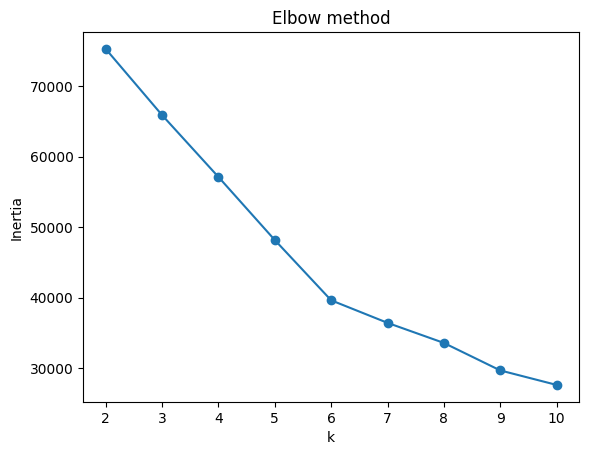

In [5]:
inertias = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()


## 2. PCA 2D + visualisation des clusters

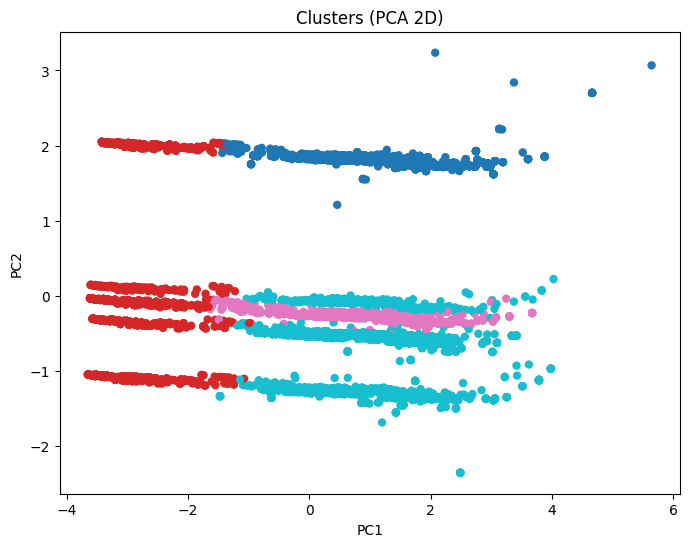

In [6]:
k = 4  # a ajuster selon l'elbow
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=25)
plt.title("Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
